In [11]:
import pandas as pd
import seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Sample data (1).xlsx")


In [12]:
df["Discount Band"]=df["Discount Band"].fillna("Unknown")

print(df.isnull().sum())

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
 Sales                 0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64


In [13]:
print(df.duplicated().sum())

0


In [17]:
df.columns=df.columns.str.strip()
print(df.columns)

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='str')


In [21]:
#How much total sales did the company generate?
sales=(round(df["Sales"].sum(), 2))
print(f"Total Sales Generated By The Company:{sales}")

Total Sales Generated By The Company:118726350.26


In [22]:
#How much total profit did the company generate?
profit = (round(df["Profit"].sum(),2))
print(f"Total Profit Generated By The Company:{profit}")

Total Profit Generated By The Company:16893702.26


In [55]:
#Which country generated the most sales?
country_sales = df.groupby("Country")["Sales"].sum().sort_index(ascending=False)
print(f"Country That Can Generated the Most Sales:{country_sales.index[0]}")

Country That Can Generated the Most Sales:United States of America


In [52]:
#Which segment generated the most profit?
segment_profit = (round(df.groupby("Segment")["Profit"].sum(),2)).sort_values(ascending=False)
print(f"Segment That Can Generated the Most Profit:{segment_profit.index[0]}")

Segment That Can Generated the Most Profit:Government


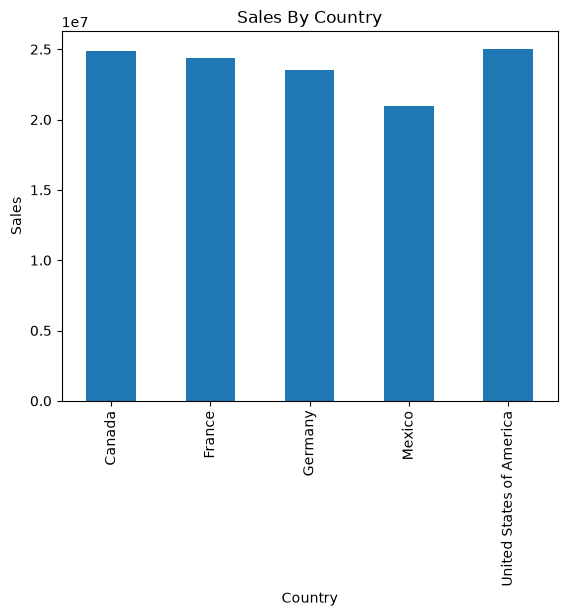

In [53]:
df.groupby("Country")["Sales"].sum().plot(kind="bar")
plt.title("Sales By Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

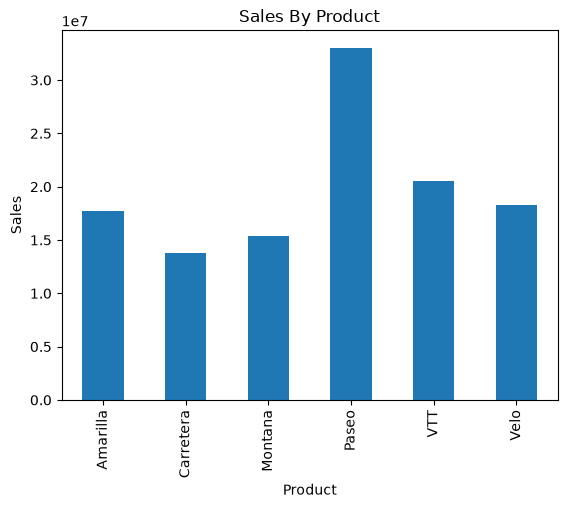

In [57]:
df.groupby("Product")["Sales"].sum().plot(kind="bar")
plt.title("Sales By Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

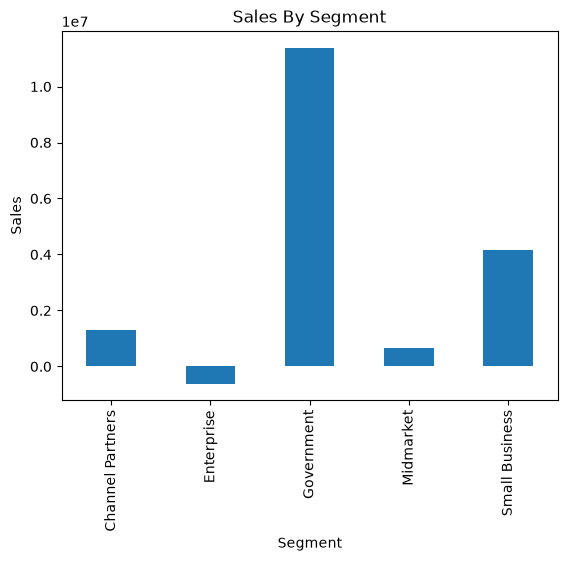

In [64]:
df.groupby("Segment")["Profit"].sum().plot(kind="bar")
plt.title("Sales By Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

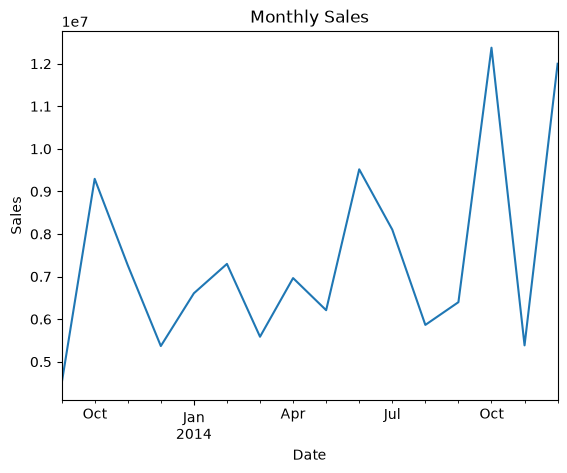

In [71]:
monthly_sales = df.groupby("Date")["Sales"].sum()
monthly_sales.plot(kind="line")
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [23]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
df = pd.read_excel("Sample Data (1).xlsx")

X = df.drop(columns=["Sales"])
y = df["Sales"]
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
df = pd.read_excel("Sample Data (1).xlsx")
X = df.drop(columns=["Sales"])
y = df["Sales"]
#Drop All Date Time Columns
X = X.select_dtypes(exclude=["datetime64","datetime"])

# 3. Convert text/categorical columns into numeric binary columns (One-Hot Encoding)
# drop_first=True helps avoid multicollinearity in linear regression
X = pd.get_dummies(X, drop_first=True)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
#Comparision Table For The First Five Rows
comparison_df = pd.DataFrame({
    "Actual Sales" : y_test.iloc[:5].values,
    "Predicted Sales" : y_pred[:5],
    "Difference (Error)" : y_test.iloc[:5].values - y_pred[:5]
})
print(comparison_df.round(2))

   Actual Sales  Predicted Sales  Difference (Error)
0      12066.60         12066.60                -0.0
1     230310.00        230310.00                 0.0
2      40769.25         40769.25                -0.0
3      27968.00         27968.00                -0.0
4      23436.00         23436.00                 0.0


In [23]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
#Mean Absolute Error
mae = mean_absolute_error(y_test,y_pred)
#Mean squared Error
mse = mean_squared_error(y_test,y_pred)
#R Square Error
r2 = r2_score(y_test,y_pred)

print(f"Mean Absolute Error:{mae:.2f}")
print(f"Mean Squared Error:{mse:.2f}")
print(f"R Square Error:{r2:.4f}")

Mean Absolute Error:0.00
Mean Squared Error:0.00
R Square Error:1.0000


In [38]:
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

comparison.head().round(2)

,Actual Sales,Predicted Sales
158,12066.60,12066.60
500,230310.00,230310.00
396,40769.25,40769.25
155,27968.00,27968.00
321,23436.00,23436.00


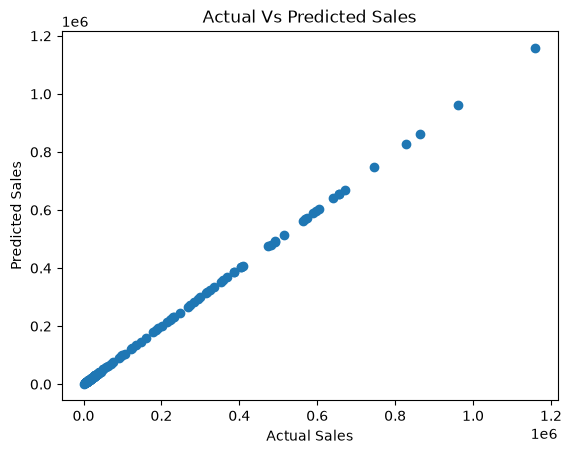

In [43]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Vs Predicted Sales")

plt.show()